# Deconvolve Chromatin Bins for CLB2

In this notebook, we will be refactoring the creation of the H matrix for the RG1 model. For Yulong's dataset, we have alpha factor arrested cells that go through recovery. We want this recovery period to incorporate the first G1, so the initial branch will be: Recovery - postG1. The calcH needs to be updated to reflect that change.

Goal:
- Refactor the creation of the H matrix
- We need to make changes to add the RG1 logic (merge R and G1 for the first c for {0, 0}

Steps:
1. Plot the growth curve to better understand the existing calc H function

In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.config import load_yl_replicate1_rg1_config, load_yl_replicate2_rg1_config, \
    load_xg_gene_expression_config
from cc_src.plot_helpers import plot_H_as_growth_curve
from src.model import Model


In [8]:
config = load_xg_gene_expression_config()
model_xg_dat = Model(config, "RNR1", 0.00)

config = load_yl_replicate1_rg1_config()
model_yl_dat = Model(config, "RNR1", 0.00)

In [9]:
xg_microarray = model_xg_dat.config.wt1_df

xg_means_df = xg_microarray[[]].copy()
xg_means_df['mean'] = xg_microarray.mean(axis=1)
xg_means_df['q20'] = xg_microarray.quantile(axis=1, q=0.2)
xg_means_df['q80'] = xg_microarray.quantile(axis=1, q=0.8)
xg_means_df['q0'] = xg_microarray.quantile(axis=1, q=0.)
xg_means_df['q100'] = xg_microarray.quantile(axis=1, q=1.)


In [10]:
yl_rna_seq = model_yl_dat.config.wt1_df

yl_rna_seq_means = yl_rna_seq[[]].copy()
yl_rna_seq_means['mean'] = yl_rna_seq.mean(axis=1)
yl_rna_seq_means['q20'] = yl_rna_seq.quantile(axis=1, q=0.2)
yl_rna_seq_means['q80'] = yl_rna_seq.quantile(axis=1, q=0.8)
yl_rna_seq_means['q0'] = yl_rna_seq.quantile(axis=1, q=0)
yl_rna_seq_means['q100'] = yl_rna_seq.quantile(axis=1, q=1.)


In [11]:
means_compare = yl_rna_seq_means.join(xg_means_df, lsuffix='_yl', rsuffix='_xg')

In [12]:
means_compare.sort_values('q0_xg').dropna().head(2)

,mean_yl,q20_yl,q80_yl,q0_yl,q100_yl,mean_xg,q20_xg,q80_xg,q0_xg,q100_xg
orf_name,,,,,,,,,,
YER175W-A,5.752191,4.770422,6.613713,3.776221,8.171658,136.011902,123.487892,144.675239,110.296086,163.513976
YCL001W-B,2.060504,1.534605,2.381278,1.279076,4.857127,134.164878,125.683292,145.149512,111.129219,152.482062


Text(0.5, 0.98, 'Microarray (Xin/Orlando) vs RNA-seq (Yulong) mean expression')

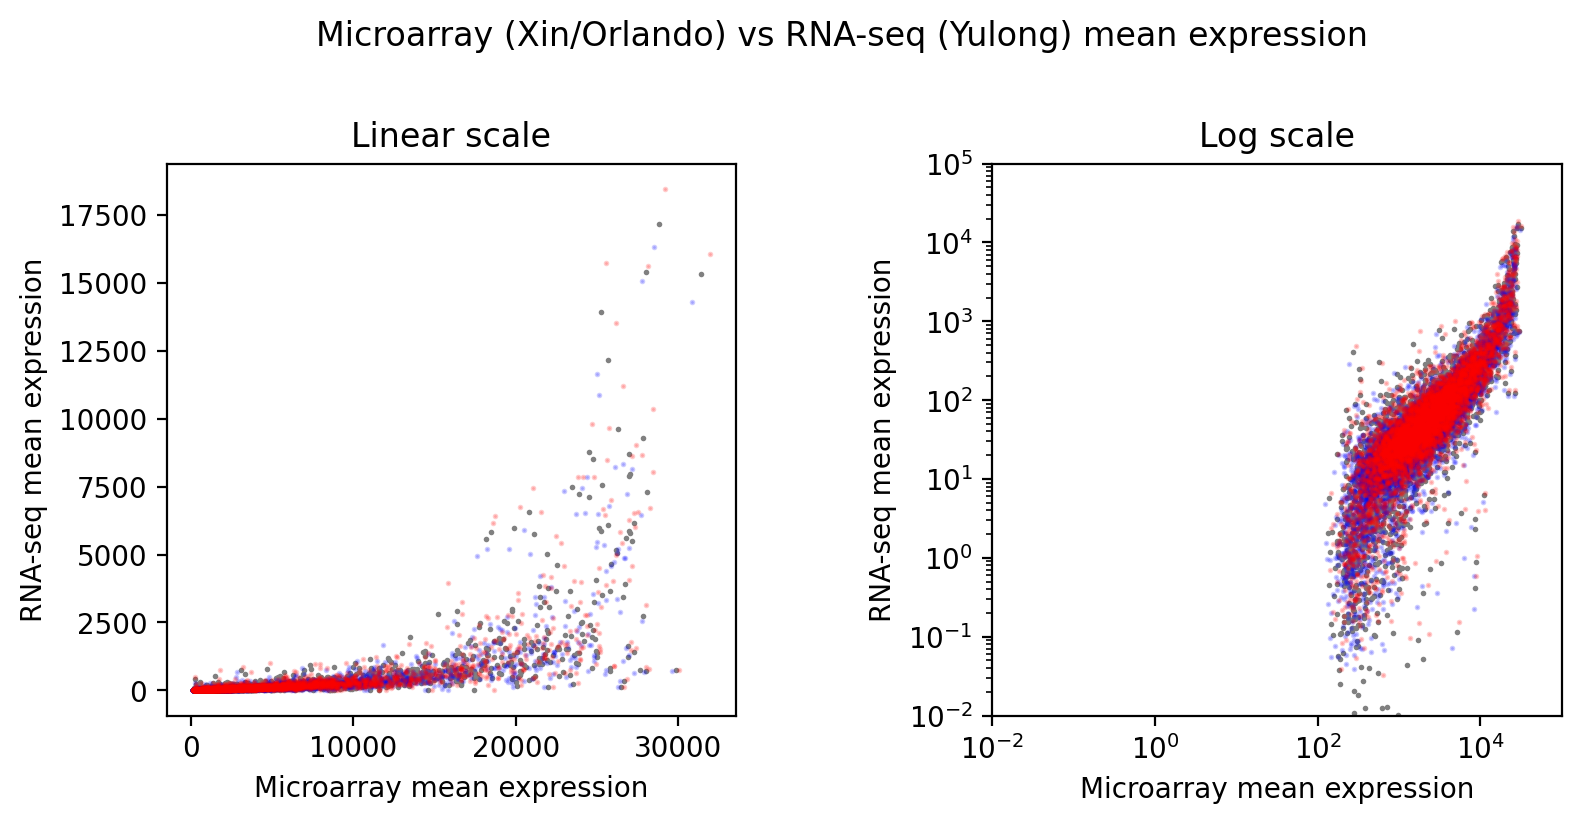

In [13]:

plt.figure(figsize=(9, 4))
plt.subplots_adjust(wspace=0.45, top=0.8)

plt.subplot(1, 2, 1)
plt.scatter(means_compare.mean_xg, means_compare.mean_yl, s=1, c='gray')
plt.xlabel("Microarray mean expression")
plt.ylabel("RNA-seq mean expression")

plt.scatter(means_compare.q20_xg, means_compare.q20_yl, s=1, c='blue', alpha=0.2)
plt.xlabel("Microarray mean expression")
plt.ylabel("RNA-seq mean expression")

plt.scatter(means_compare.q80_xg, means_compare.q80_yl, s=1, c='red', alpha=0.2)
plt.xlabel("Microarray mean expression")
plt.ylabel("RNA-seq mean expression")
plt.title("Linear scale")

plt.subplot(1, 2, 2)
plt.scatter(means_compare.mean_xg, means_compare.mean_yl, s=1, c='gray')
plt.xlabel("Microarray mean expression")
plt.ylabel("RNA-seq mean expression")

plt.scatter(means_compare.q20_xg, means_compare.q20_yl, s=1, c='blue', alpha=0.2)
plt.xlabel("Microarray mean expression")
plt.ylabel("RNA-seq mean expression")

plt.scatter(means_compare.q80_xg, means_compare.q80_yl, s=1, c='red', alpha=0.2)
plt.xlabel("Microarray mean expression")
plt.ylabel("RNA-seq mean expression")

plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-2, 1e5)
plt.xlim(1e-2, 1e5)
plt.title("Log scale")

plt.suptitle("Microarray (Xin/Orlando) vs RNA-seq (Yulong) mean expression")

In [14]:

# Let's try to normalize the replcate 1 gene expression counts using the median of ratios

import pandas as pd
import numpy as np

# Assuming 'counts' is a DataFrame with genes as rows and samples as columns
def median_of_ratios_normalization(counts):
    
    # Calculate the geometric mean for each gene
    counts = counts + 1
    
    geometric_means = counts.apply(lambda x: np.exp(np.mean(np.log(x[x > 0]))), axis=1)

    # Calculate the size factors
    size_factors = counts.div(geometric_means, axis=0).apply(np.median, axis=0)

    # Normalize the counts
    normalized_counts = counts.div(size_factors, axis=1)
    
    return geometric_means, size_factors, normalized_counts,

In [15]:
rep1_read_counts = pd.read_csv('datasets/yl_cell_cycle/'+
       'replicate1_gene_expression_counts.csv').set_index('orf_name')

(geometric_means,
 size_factors,
 normalized_counts) = median_of_ratios_normalization(rep1_read_counts)



In [16]:
mean_rep1_mor = normalized_counts[[]].copy()
mean_rep1_mor['mean_rep1_mor'] = normalized_counts.mean(axis=1)
means_compare_mor = means_compare.join(mean_rep1_mor)
means_compare_mor.head(2)

,mean_yl,q20_yl,q80_yl,q0_yl,q100_yl,mean_xg,q20_xg,q80_xg,q0_xg,q100_xg,mean_rep1_mor
orf_name,,,,,,,,,,,
YAL068C,0.044325,0.0,0.096026,0.0,0.119821,1262.488439,1150.292971,1376.638146,1102.646350,1501.547254,1.450260
YAL067W-A,0.000000,0.0,0.000000,0.0,0.000000,191.622914,183.127936,191.288104,175.146738,242.782479,1.005081


In [17]:
rep1_deseq2 = pd.read_csv('datasets/yl_cell_cycle/replicate1_deseq2.csv')
rep1_deseq2.columns = ['orf_name'] + list(rep1_read_counts.columns)
rep1_deseq2 = rep1_deseq2.set_index('orf_name')

means_compare_mor['mean_rep1_deseq2'] = rep1_deseq2.mean(axis=1)
means_compare_mor.head(2)

,mean_yl,q20_yl,q80_yl,q0_yl,q100_yl,mean_xg,q20_xg,q80_xg,q0_xg,q100_xg,mean_rep1_mor,mean_rep1_deseq2
orf_name,,,,,,,,,,,,
YAL068C,0.044325,0.0,0.096026,0.0,0.119821,1262.488439,1150.292971,1376.638146,1102.646350,1501.547254,1.450260,0.445639
YAL067W-A,0.000000,0.0,0.000000,0.0,0.000000,191.622914,183.127936,191.288104,175.146738,242.782479,1.005081,0.000000


In [24]:
rep1_deseq2_vst = pd.read_csv('datasets/yl_cell_cycle/replicate1_deseq2_vst_counts.csv')
rep1_deseq2_vst.columns = ['orf_name'] + list(rep1_read_counts.columns)
rep1_deseq2_vst = rep1_deseq2_vst.set_index('orf_name')

means_compare_mor['mean_rep1_deseq2_vst'] = rep1_deseq2_vst.mean(axis=1)
means_compare_mor.head(2)


,mean_yl,q20_yl,q80_yl,q0_yl,q100_yl,mean_xg,q20_xg,q80_xg,q0_xg,q100_xg,mean_rep1_mor,mean_rep1_deseq2,mean_rep1_deseq2_vst
orf_name,,,,,,,,,,,,,
YAL068C,0.044325,0.0,0.096026,0.0,0.119821,1262.488439,1150.292971,1376.638146,1102.646350,1501.547254,1.450260,0.445639,3.773862
YAL067W-A,0.000000,0.0,0.000000,0.0,0.000000,191.622914,183.127936,191.288104,175.146738,242.782479,1.005081,0.000000,3.585061


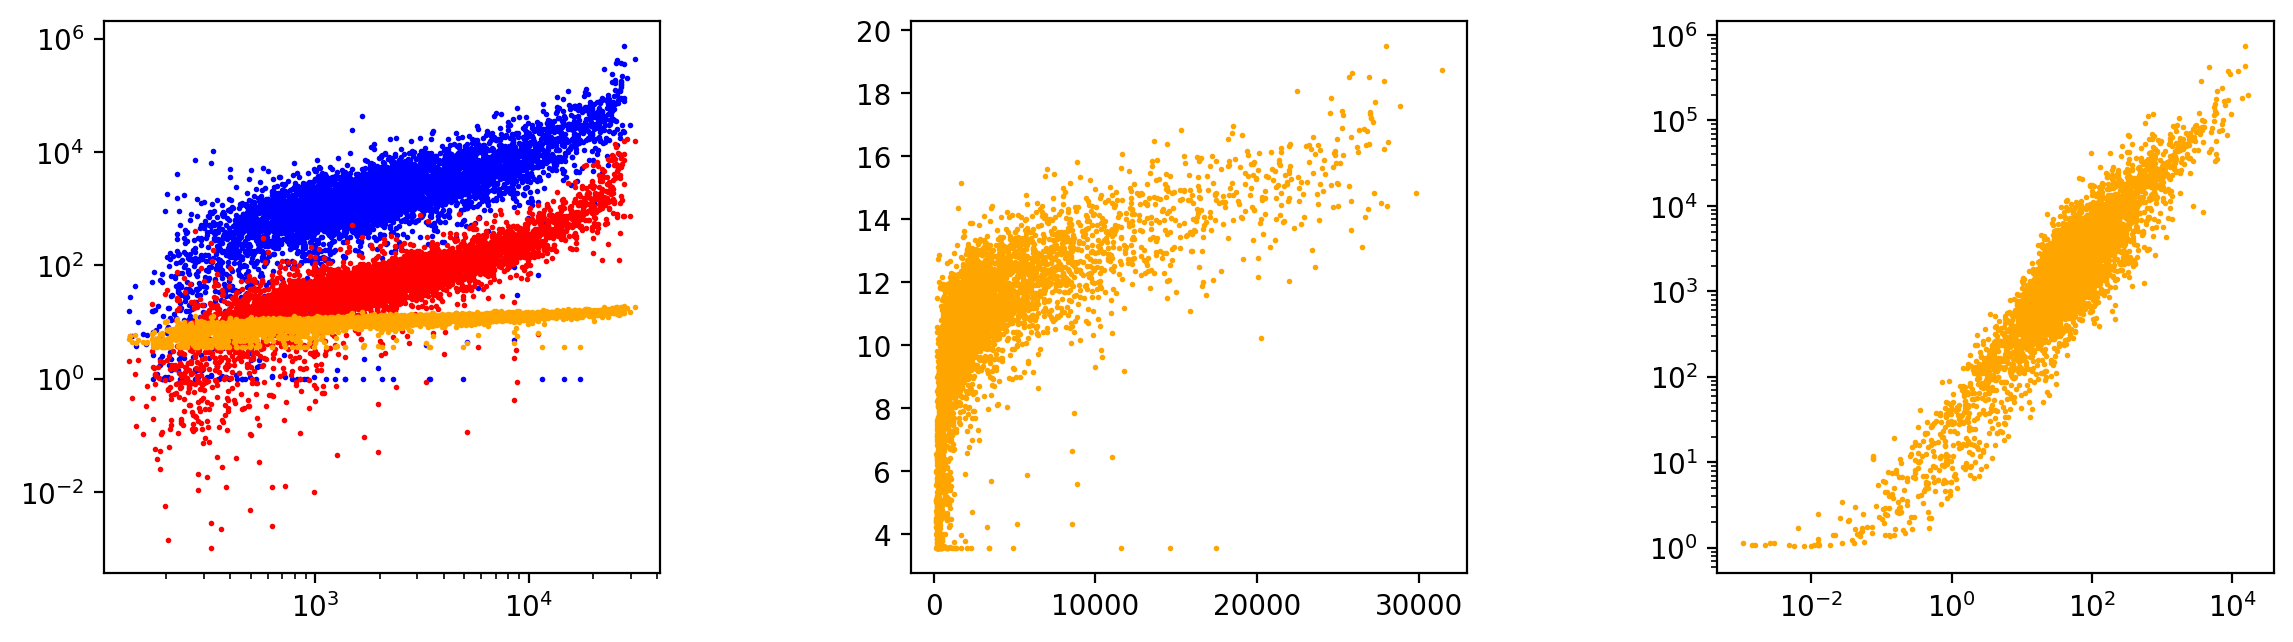

In [59]:

plt.figure(figsize=(14, 4))
plt.subplots_adjust(wspace=0.45, top=0.8)

plt.subplot(1, 3, 1)
plt.scatter(means_compare_mor.mean_xg, means_compare_mor.mean_rep1_mor, s=1, c='blue')
plt.scatter(means_compare_mor.mean_xg, means_compare_mor.mean_yl, s=1, c='red')
plt.scatter(means_compare_mor.mean_xg, means_compare_mor.mean_rep1_deseq2_vst, s=1, c='orange')

plt.yscale('log')
plt.xscale('log')

plt.subplot(1, 3, 2)
plt.scatter(means_compare_mor.mean_xg, means_compare_mor.mean_rep1_deseq2_vst, s=1, c='orange')

plt.subplot(1, 3, 3)
plt.scatter(means_compare_mor['mean_yl'], means_compare_mor.mean_rep1_mor, s=1, c='orange')

plt.xscale('log')
plt.yscale('log')
